In [1]:
%config Completer.use_jedi = False
import warnings
warnings.filterwarnings("ignore")
import datetime
import tensorflow as tf
import pandas as pd
import numpy as np
import os, sys
import time
sys.path.append(os.path.join(os.getcwd(), '../../common'))
from utils import timer, save, load
pd.set_option('display.max_columns', None)

In [2]:
os.getcwd()

'/Users/qingbin.zhuang/Personal/StockProject/Tutorial/YoutubeClass'

In [18]:
class T(object):
    pass

t = T()

In [21]:
type(T), type(t), T.__class__, t.__class__, T.__class__.__class__, t.__class__.__class__

(type, __main__.T, type, __main__.T, type, type)

In [22]:
dir(T)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__']

In [32]:
str(T), str(t)

("<class '__main__.T'>", '<__main__.T object at 0x7f83df96cd30>')

In [29]:
print(T), print(t)

<class '__main__.T'>


(None, None)

In [17]:
T

__main__.T

In [3]:
import datetime
import backtrader as bt
import pandas as pd
import matplotlib

In [2]:
class MyStrategy(bt.Strategy):
    pass

In [3]:
# 1 Create a cerebro
cerebro = bt.Cerebro()

In [4]:
# 2. Add data feed
# 2.1 Create a data feed
dataframe = pd.read_csv("AAPL.csv")
dataframe['Date'] = pd.to_datetime(dataframe['Date'])
dataframe.set_index("Date", inplace = True)
dataframe["openinterest"] = 0
brf_daily = bt.feeds.PandasData(
    dataname = dataframe,
    fromdate = datetime.datetime(2021,12,31),
    todate = datetime.datetime(2022,12,1)
)
# brf_daily = bt.feeds.GenericCSVData(
#     dataname = 'AAPL.csv', 
#     fromdate = datetime.datetime(2021,12,31),
#     todate = datetime.datetime(2022,12,1),
# #     nullvalue = 0,
#     dtformat = "%Y-%m-%d",
#     datetime = 0, # 第一列
#     open = 1, # 第二列
#     high=2,
#     low=3,
#     close=4,
#     volume=6,
#     openinterest=-1 # 不存在这个数据
# )

In [5]:
# 2.2 Add the Data Feed to Cerebro
cerebro.adddata(brf_daily)

In [6]:
# 3 Add strategy
cerebro.addstrategy(MyStrategy)

0

In [7]:
# 4 run
cerebro.run()

<IPython.core.display.Javascript object>


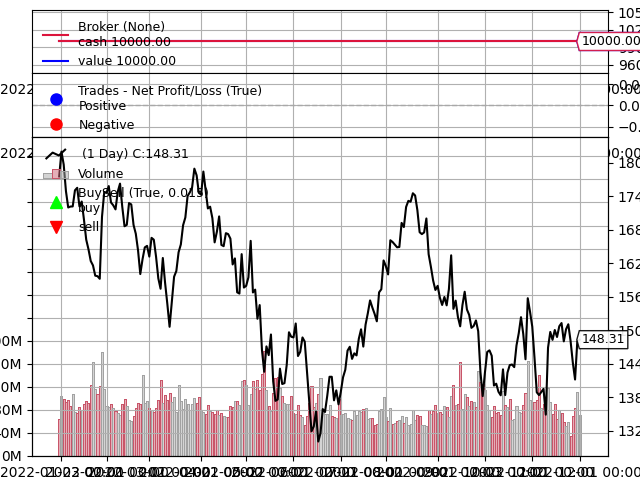

<IPython.core.display.Javascript object>


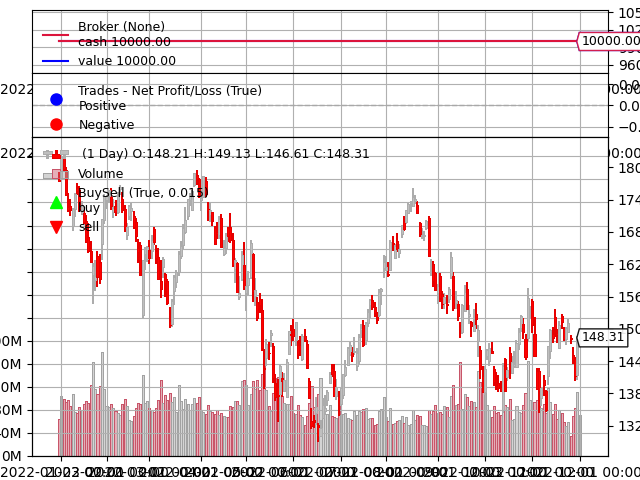

[[<Figure size 640x480 with 4 Axes>]]

In [8]:
# 5 Plot result
cerebro.plot()
cerebro.plot(style='candle')

# 理解Strategy类

In [27]:
# Strategy类
class MyStrategy(bt.Strategy):
    def __init__(self):
        print("init")
    
    def start(self):
        print("The world call me!")
    
    def prenext(self):
        print("Not mature")
        
    def nextstart(self):
        print("Rites of passage")
        
    def next(self):
        print("A new bar")
        
    def stop(self):
        print("I should leave the world")

In [35]:
brf_daily = bt.feeds.GenericCSVData(
    dataname = 'AAPL.csv', 
    fromdate = datetime.datetime(2022,10,31),
    todate = datetime.datetime(2022,11,2),
#     nullvalue = 0,
    dtformat = "%Y-%m-%d",
    datetime = 0, # 第一列
    open = 1, # 第二列
    high=2,
    low=3,
    close=4,
    volume=6,
    openinterest=-1 # 不存在这个数据
)

In [36]:
# Strategy类
class MyStrategy(bt.Strategy):
    def __init__(self):
        print("init")
    
    def start(self):
        print("The world call me!")
    
    def prenext(self):
        print("Not mature")
        
    def nextstart(self):
        print("Rites of passage")
        
    def next(self):
        # 当一个bar调用一次
        print("A new bar")
        
    def stop(self):
        print("I should leave the world")

In [37]:
cerebro = bt.Cerebro()
cerebro.adddata(brf_daily)
cerebro.addstrategy(MyStrategy)
cerebro.run()

init
The world call me!
Rites of passage
A new bar
I should leave the world


In [39]:
# SMA策略
## Backtrader中line的概念（数据流）和line的操作
## 自己动手计算SMA
## Buy和Sell的命令（买卖多少的数量）
## Backtrader使用SMA的正确姿势（indicator也是line）

In [4]:
brf_daily = bt.feeds.GenericCSVData(
    dataname = 'AAPL.csv', 
#     fromdate = datetime.datetime(2022,10,31),
#     todate = datetime.datetime(2022,11,2),
#     nullvalue = 0,
    dtformat = "%Y-%m-%d",
    datetime = 0, # 第一列
    open = 1, # 第二列
    high=2,
    low=3,
    close=4,
    volume=6,
    openinterest=-1 # 不存在这个数据
)

In [71]:
# Strategy类
class MyStrategy(bt.Strategy):
    def __init__(self):
        print("init")
    
    def start(self):
        print("The world call me!")
    
    def prenext(self):
        print("Not mature")
        
    def nextstart(self):
        print("Rites of passage")
        
    def next(self):
        # 当一个bar调用一次
        print("A new bar: " , self.data.datetime.date())
        ## self.data 就是 DataFeed, .close就是DataFeed的close价格 
        ## [0]代表当前时间点 [-1]代表昨天数据
#         print(self.data.close[0])
        
        ## 实现MA策略
        ma_value = sum(self.data.close[-cnt] for cnt in range(0,5)) / 5
        print(ma_value, self.data.close[-4], self.data.close[0])
        if self.data.close[0] > ma_value and self.data.close[-1] < ma_value:
            print("long: ", self.data.datetime.date())
            self.order = self.buy(size=1) # 买一手
        
        if self.data.close[0] < ma_value and self.data.close[-1] > ma_value:
            print("long: ", self.data.datetime.date())
            self.order = self.sell(size=1) # 卖一手
        
    def stop(self):
        print("I should leave the world")

In [72]:
cerebro = bt.Cerebro()
cerebro.adddata(brf_daily)
cerebro.addstrategy(MyStrategy)
cerebro.run()
# cerebro.plot(style='candle')

init
The world call me!
Rites of passage
A new bar:  2021-12-14
155.16400140000002 140.940002 174.330002
A new bar:  2021-12-15
162.83600159999997 142.649994 179.300003
A new bar:  2021-12-16
168.7580018 142.160004 172.259995
A new bar:  2021-12-17
174.55400079999998 175.740005 171.139999
A new bar:  2021-12-20
173.3559998 174.330002 169.75
A new bar:  2021-12-21
173.0880004 179.300003 172.990005
A new bar:  2021-12-22
172.3559996 172.259995 175.639999
A new bar:  2021-12-23
173.1600004 171.139999 176.279999
A new bar:  2021-12-27
174.998001 169.75 180.330002
A new bar:  2021-12-28
176.9059996 172.990005 179.289993
A new bar:  2021-12-29
178.1839996 175.639999 179.380005
A new bar:  2021-12-30
178.69599920000002 176.279999 178.199997
long:  2021-12-30
A new bar:  2021-12-31
178.9540008 180.330002 177.570007
A new bar:  2022-01-03
179.2899994 179.289993 182.009995
long:  2022-01-03
A new bar:  2022-01-04
179.3720002 179.380005 179.699997
A new bar:  2022-01-05
178.47999880000003 178.199

In [56]:
dataframe.head()

,Open,High,Low,Close,Adj Close,Volume,openinterest
Date,,,,,,,
2021-12-13,181.119995,182.130005,175.529999,175.740005,174.725937,153237000,0
2021-12-14,175.250000,177.740005,172.210007,174.330002,173.324081,139380400,0
2021-12-15,175.110001,179.500000,172.309998,179.300003,178.265411,131063300,0
2021-12-16,179.279999,181.139999,170.750000,172.259995,171.266006,150185800,0
2021-12-17,169.929993,173.470001,169.690002,171.139999,170.152466,195432700,0


<IPython.core.display.Javascript object>


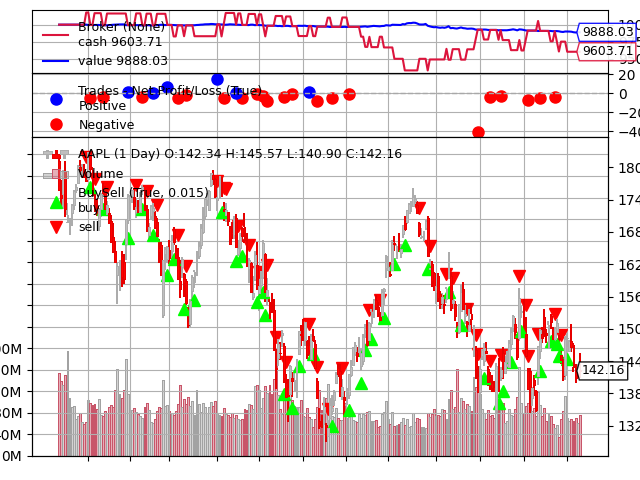

[[<Figure size 640x480 with 4 Axes>]]

In [73]:
cerebro.plot(style='candle')

In [74]:
# SMA策略2

In [14]:
brf_daily = bt.feeds.GenericCSVData(
    dataname = 'AAPL.csv', 
#     fromdate = datetime.datetime(2022,10,31),
#     todate = datetime.datetime(2022,11,2),
#     nullvalue = 0,
    dtformat = "%Y-%m-%d",
    datetime = 0, # 第一列
    open = 1, # 第二列
    high=2,
    low=3,
    close=4,
    volume=6,
    openinterest=-1 # 不存在这个数据
)

# Strategy类
class MyStrategy(bt.Strategy):
    def __init__(self):
        # bt_sma也是一个line 操作和data feed一样
        self.bt_sma = bt.indicators.MovingAverageSimple(self.data, period=30)
        
        self.buy_sell_signal = bt.indicators.CrossOver(self.data.close, self.bt_sma)
    def start(self):
        print("The world call me!")
    
    def prenext(self):
        print("Not mature")
        
    def nextstart(self):
        print("Rites of passage")
        
    def next(self):
        # 当一个bar调用一次
        print("A new bar: " , self.data.datetime.date())
        ## self.data 就是 DataFeed, .close就是DataFeed的close价格 
        ## [0]代表当前时间点 [-1]代表昨天数据
#         print(self.data.close[0])
        
        ## 实现MA策略
#         ma_value = sum(self.data.close[-cnt] for cnt in range(0,5)) / 5
        ma_value = self.bt_sma[0]
        pre_ma_value = self.bt_sma[-1]
        print(ma_value, self.data.close[-4], self.data.close[0])
        
        # 没有仓位且上穿
        if not self.position and self.buy_sell_signal[0] == 1:
            self.order = self.buy()
        if not self.position and self.buy_sell_signal[0] == -1:
            self.order = self.sell()
            
        if self.position and self.buy_sell_signal[0] == 1:
            # 说明之前是空头 清仓
            self.order = self.close()
            self.order = self.buy()
        if self.position and self.buy_sell_signal[0] == -1:
            self.order = self.close()
            self.order = self.sell()
            
        
        
    def stop(self):
        print("I should leave the world")

In [15]:
cerebro = bt.Cerebro()
cerebro.adddata(brf_daily)
cerebro.addstrategy(MyStrategy)
cerebro.run()
# cerebro.plot(style='candle')

The world call me!
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Not mature
Rites of passage
A new bar:  2022-01-27
172.14166663333333 162.410004 159.220001
A new bar:  2022-01-28
171.8426666 161.619995 170.330002
A new bar:  2022-01-31
171.92666673333332 159.779999 174.779999
A new bar:  2022-02-01
172.04233346666666 159.690002 174.610001
A new bar:  2022-02-02
172.24533333333332 159.220001 175.839996
A new bar:  2022-02-03
172.24233296666668 170.330002 172.899994
A new bar:  2022-02-04
172.13399963333333 174.779999 172.389999
A new bar:  2022-02-07
171.9799998 174.610001 171.660004
A new bar:  2022-02-08
171.79666646666666 175.839996 174.830002
A new bar:  2022-02-09
171.69633333333334 172.899994 176.279999
A new ba

<IPython.core.display.Javascript object>


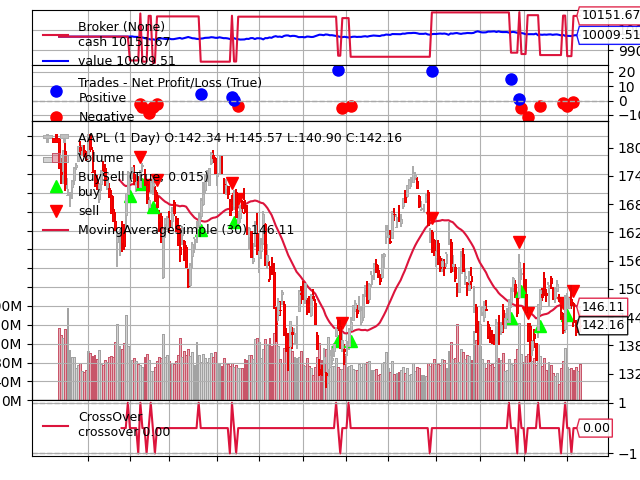

[[<Figure size 640x480 with 5 Axes>]]

In [16]:
cerebro.plot(style='candle')

In [5]:
# 自定义 indicator
## 继承Indicator基类
## 明确指标中有哪些line
## 明确有哪些参数
## 在init函数中初始化Indicator一些参数、特性
## 在next中定义每一个line的数值 -- 定义好之前明确的line的值
class three_bars(bt.Indicator):
    lines = ('up', 'down')  # 定义line: up 和 down
    
    # params = (('period', 20),) # 定义参数 period参数为20
    
    def __init__(self):
        # 第4个k线开始才能计算Indicator
        self.addminperiod(4)
        # 控制把这个Indicator画在主图上
        self.plotinfo.plotmaster = self.data
        
    def next(self):
        # up这个line的当天值 - lines[0]
        self.lines[0][0] = max(max(self.data.close.get(ago=-1,size=3)),
                               max(self.data.open.get(ago=-1,size=3)))
        # down这个line的当天值 [0]
        self.down[0] = min(min(self.data.close.get(ago=-1,size=3)),
                               min(self.data.open.get(ago=-1,size=3)))
class MyStrategy(bt.Strategy):
    def __init__(self):
        self.up_down = three_bars(self.data)
        self.buy_signal = bt.indicators.CrossOver(self.data.close, self.up_down.up)
        # buy_signal 这个Indicator不打印
        self.buy_signal.plotinfo.plot = False
        self.sell_signal = bt.indicators.CrossOver(self.data.close, self.up_down.down)
        
    def next(self):
        if not self.position and self.buy_signal[0] == 1:
            # 以第二天的开盘价买进
            self.order = self.buy()
        
        if self.getposition().size < 0 and self.buy_signal[0] == 1:
            # 平掉空头 再买入
            self.order = self.close()
            self.order = self.buy()
            
        if not self.position and self.sell_signal[0] == 1:
            self.order = self.sell()
        
        if self.getposition().size > 0 and self.sell_signal[0] == 1:
            self.order = self.close()
            self.order = self.sell()
        

<IPython.core.display.Javascript object>


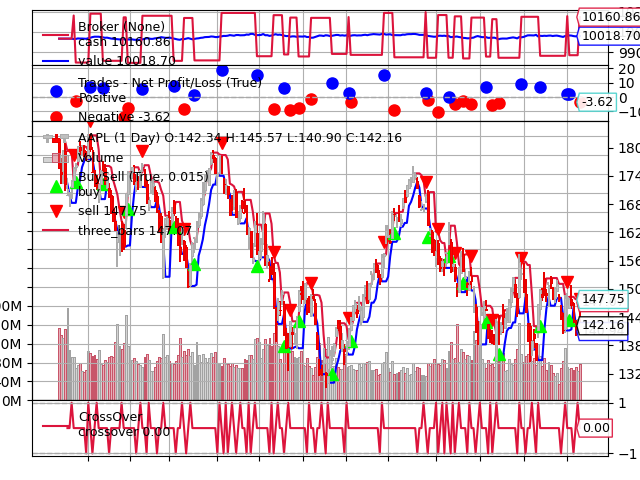

[[<Figure size 640x480 with 5 Axes>]]

In [6]:
cerebro = bt.Cerebro()
cerebro.adddata(brf_daily)
cerebro.addstrategy(MyStrategy)
cerebro.run()
cerebro.plot(style='candle')

In [ ]:
## Dual thrust策略实现
### Dayily bar产生信号 分钟线回测 分钟线交易
### 用来交易的bar称为main bar 通常是时间颗粒最小的bar线




In [ ]:
## DataFeed 的 resampling
brf_min_bar = bt.feeds.PandasData(
    dataname=dataframe,
    timeframe=bt.TimeFrame.Minutes # 告诉输入的数据是分钟级别的
)

cerebro = bt.Cerebro()
cerebro.adddata(brf_min_bar)
# 把分钟级别数据投射到天级数据
cerebro.resampledata(brf_min_bar, timeframe=bt.TimeFrame.Days) 

In [8]:
class DT_Line(bt.Indicator):
    lines = ('U', 'D')
    params = (('period', 2), ('k_u', 0.7), ('k_d', 0.7))
    
    def __init__(self):
        self.addminperiod(self.p.period + 1)
        
    def next(self):
        HH = max(self.data.high.get(-1, size = self.p.period))
        LC = min(self.data.close.get(-1, size = self.p.period))
        HC = max(self.data.close.get(-1, size = self.p.period))
        LL = min(self.data.low.get(-1, size = self.p.period))
        
        R = max(HH - LC, HC - LL)
        self.lines.U[0] = self.data.open[0] + self.p.k_u * R
        self.lines.D[0] = self.data.open[0] - self.p.k_d * R
        
class DualThrust(bt.Strategy):
    params = (('period', 2), ('k_u', 0.7), ('k_d', 0.7))
    def __init__(self):
        # 在DataFeed中 self.data 和 self.data0 是等价的
        ###  self.data 是 main data 就是第一个加入的data -- Strategy是按照分钟来的
        ### self.data0 是第一个加入的data
        # 这里 data和data0 就是 分钟级数据 
        self.dataclose = self.data0.close 
        # data1 就是 天级数据
        self.D_line = DT_Line(self.data1, period = self.p.period,
                             k_u = self.p.k_u, k_d = self.p.k_d)
        self.data1.plotinfo.plot = False
        
        # 注意： D_line是天级的数据 直接画在data1 数据点对不齐
        self.D_line = self.D_line()
        self.D_line.plotinfo.plotmaster = self.data1
        
        # 交易信号
        self.buy_signal = bt.indicator.CrossOver(self.dataclose, self.D_line.U)
        self.sell_signal = bt.indicator.CrossOver(self.dataclose, self.D_line.D)
        
    def start(self):
        print("Start")
        
    def prenext(self):
        print("Not mature")
    
    def next(self):
        # 在指定时间段才交易
        if self.data.datetime.time() > datetime.time(9, 3) and
            self.data.datetime.time() < datetime.time(22, 55):
                
            if not self.position ans self.buy_signal[0] == 1:
                self.order = self.buy()
            if not self.position ans self.sell_singal[0] == 1:
                self.order = self.sell()

            if self.getpositon().size < 0 and self.buy_signal[0] == 1:
                self.order = self.close()
                self.order = self.buy()
            if self.getpositon().size > 0 and self.sell_singal[0] == 1:
                self.order = self.close()
                self.order = self.sell()
        # 日内平仓
        elif self.data.datetime.time() >= datetime.time(22, 55) and self.position:
            self.order = self.close()
            
    def stop(self):
        print("period: %s, k_u: %s, k_d: %s, final_value: %.2f" %
             (self.p.period, self.p.k_u, self.p.k_d, self.broker.getvalue()))

In [ ]:
cerebro.addstrategy(DualThrust)

In [ ]:
cerebro.run()
cerebro.plot()


In [ ]:
## 策略优化器

cecebro.optstrategy(
    DuakThrust,
    period = range(1,5),
    k_u = [n / 10 for n in range(2,10)],
    k_d = [n / 10 for n in range(2,10)]
)

In [ ]:
## 交易参数设置和获取
# commision 手续费
# margin 保证金
# mult 点数
# name 适用的DataFeed 不指定则适用所有

# 设置了 margin和mult之后 commission默认就是绝对数值
cerebro.broker.setcommission(commission=2.0,margin=2000.0,mult=10.0)

# 不设置 margin和mult之后 commission就是百分比数值
cerebro.broker.setcommission(commission=0.0005)



In [ ]:
## 滑点设置参数
# default 0.0 固定滑点
cerebro.broker.set_slippage_fixed(fixed=5)
# default 0.0 滑点百分比 0.01为1%滑点
cerebro.broker.set_slippage_perc(perc=0.05)


In [ ]:
## Filler设置参数 -- 大单需要参考真实每分钟成交的量
# 每一根bar成交量的百分比作为这一根bar的最大成交量
# 我现在下单之后 接下来的每一根k线都只能按照10分之一的成交量成交，如果超过则递延到下一个bar
cerebro.broker.set_filler(bt.broker.fillers.FixedBarPerc(perc=0.1))
# 每一根bar的绝对最大成交量 -- 最多只成交20个
cerebro.broker.set_filler(bt.broker.filler.FixedSize(size=20))

In [ ]:
# Writer
## 记录策略效果
cerebro.addwriter(bt.WriterFile, csv = True, out='filename')
res = cerebro.run()[0]

In [ ]:
## broker的数据获取
get_cash() # 还有多少现金
get_value(datas=None) # 
getposition(data) # 返回一个position对象
# Position对象的成员变量
# size - 当前头寸大小 多头为正 空头为负
# price - 当存头寸价格

In [ ]:
## Observes
# 监测交易过程中一直存在的数据，
# 这里的value cash和trades是Backtrader默认自己添加的Observer
cerebro = bt.Cerebro(stdstats = False) # 取消这种默认参数
cerebro.addobserver(bt.observers.Broker)
cerebro.addobserver(bt.observers.Trades)
cerebro.addobserver(bt.observers.BuySell)
cerebro.addobserver(bt.observers.DrawDown)
cerebro.addobserver(bt.observers.Value)
cerebro.addobserver(bt.observers.TimeReturn)


In [ ]:
## Analysis
# 结果性指标 最后计算
cerebro.addanalyzer(bt.analyzers.SharpeRatio)

res = cerebro.run()[0] # bt支持多策略 第一个策略
print("SharpeRatio: ", res.analyzers.sharperatio.get_analysis())

In [ ]:
# pyfolio
cerebro.addanalyzer(bt.analyzers.PyFolio)
res = cerebro.run()[0]

pyfolio = res.analyzers.getbyname("pyfolio")
returns, positions, transactions, gross_lev = pyfolio.get_pf_items()
returns.to_hdf("return.h5", key = "data")
positions.to_hdf("position.h5", key = "data")
transactions.to_hdf("transactions.h5", key = "data")

In [ ]:
import pyfoilo as pf
pf.create_full_tear_sheet(
    returns,
    positions
)